In [1]:
%load_ext autoreload
%autoreload 2
# %env CUDA_VISIBLE_DEVICES=0

## Prelims

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


In [3]:
split_id = 11042026
pd.set_option('display.max_rows', None)


In [4]:
from omegaconf import OmegaConf
log_dir = 'log_dir'
hostname_ = 'CIN'
dataset_name = 'areds_new'
project_dir = '/gpfs01/berens/user/inwabufo/leverage/leverage-data'
CLEANED_FILE= 'areds_new_results_cleaned_03_06_26_split_id_11042026'
config_file = '/gpfs01/berens/user/inwabufo/.secrets.yaml'
cfg = OmegaConf.load(config_file)
CHKPT_DIR = chkpt_dir = os.path.join(project_dir, 'chkpt_dir', 'npj_areds_curves')
RESULTS_DIR = os.path.join(project_dir, 'results')
project_dir = cfg['DATASETS'][hostname_][dataset_name]
stylef = cfg['stylef'][hostname_]
img_dir = f"{project_dir}"
img_dir

'/gpfs01/berens/user/inwabufo/data/AREDS/AREDS_macula'

In [5]:

df2 = pd.read_csv(os.path.join(log_dir, f"{CLEANED_FILE}.csv"))
df2['summary'].value_counts()

summary
simclr_inet_nako    140
dino_nako           140
simclr_nako         140
resnet_imagenet     140
retfound            140
dino_meta           140
nako_mae            140
scratch             140
Name: count, dtype: int64

In [6]:
def make_families(x):
    family= None
    if (x =='simclr_nako') or (x == 'simclr_inet_nako') or (x=='nako_mae'):
        family = 'SSL'
    elif (x=='dino_meta') or (x=='dino_nako') or (x=='retfound'):
        family = 'FM'
    elif (x=='scratch') or (x=='resnet_imagenet'):
        family = 'Sup.'
    else:
        raise ValueError('Unknown')
    return family

In [7]:
df2['model_family'] = df2['summary'].apply(lambda x: make_families(x) )
df2['model_family'].value_counts(dropna = False)

model_family
SSL     420
FM      420
Sup.    280
Name: count, dtype: int64

In [8]:
dino_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "dino_nako") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "dino_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "dino_nako") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "dino_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_nako_mlp_fef.shape, dino_nako_mlp_fet.shape, dino_nako_lin_fef.shape, dino_nako_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [9]:
dino_nako_mlp_fef['train_size'].value_counts()

train_size
100.0      5
500.0      5
20000.0    5
10000.0    5
1000.0     5
30000.0    5
32500.0    5
Name: count, dtype: int64

In [10]:
dino_meta_lin_fef = pd.DataFrame(df2[(df2['summary']  == "dino_meta")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_meta_lin_fet = pd.DataFrame(df2[(df2['summary']  == "dino_meta")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_meta_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "dino_meta")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_meta_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "dino_meta")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_meta_mlp_fef.shape, dino_meta_mlp_fet.shape, dino_meta_lin_fef.shape, dino_meta_lin_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [11]:
dino_meta_mlp_fef['train_size'].value_counts(dropna=False), dino_meta_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 500.0      5
 10000.0    5
 32500.0    5
 100.0      5
 20000.0    5
 1000.0     5
 30000.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 32500.0    5
 30000.0    5
 Name: count, dtype: int64)

In [12]:
simclr_inet_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_inet_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_inet_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_inet_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_inet_nako_lin_fef.shape, simclr_inet_nako_lin_fet.shape, simclr_inet_nako_mlp_fef.shape, simclr_inet_nako_mlp_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [13]:
simclr_inet_nako_mlp_fet['train_size'].value_counts(dropna=False), simclr_inet_nako_mlp_fef['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 20000.0    5
 500.0      5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 30000.0    5
 10000.0    5
 1000.0     5
 32500.0    5
 Name: count, dtype: int64)

In [14]:
simclr_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_nako_mlp_fef.shape, simclr_nako_mlp_fet.shape, simclr_nako_lin_fef.shape, simclr_nako_lin_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [15]:
simclr_nako_mlp_fef['train_size'].value_counts(dropna=False), simclr_nako_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64)

In [16]:
imagenet_resnet_lin_fef = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
imagenet_resnet_lin_fet = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
imagenet_resnet_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
imagenet_resnet_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
imagenet_resnet_mlp_fef.shape, imagenet_resnet_mlp_fet.shape, imagenet_resnet_lin_fef.shape, imagenet_resnet_lin_fet.shape


((35, 72), (35, 72), (35, 72), (35, 72))

In [17]:
imagenet_resnet_mlp_fef['train_size'].value_counts(dropna=False), imagenet_resnet_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 20000.0    5
 30000.0    5
 1000.0     5
 100.0      5
 500.0      5
 10000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 32500.0    5
 30000.0    5
 20000.0    5
 10000.0    5
 1000.0     5
 500.0      5
 Name: count, dtype: int64)

In [18]:
resnet_scratch_lin_fef = pd.DataFrame(df2[(df2['summary']  == "scratch") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
resnet_scratch_lin_fet = pd.DataFrame(df2[(df2['summary']  == "scratch")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
resnet_scratch_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "scratch") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
resnet_scratch_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "scratch")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
resnet_scratch_mlp_fef.shape, resnet_scratch_mlp_fet.shape, resnet_scratch_lin_fef.shape, resnet_scratch_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [19]:
resnet_scratch_mlp_fef['train_size'].value_counts(dropna=False), resnet_scratch_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 32500.0    5
 20000.0    5
 10000.0    5
 500.0      5
 1000.0     5
 30000.0    5
 Name: count, dtype: int64)

In [20]:
retfound_lin_fef = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
retfound_lin_fet = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
retfound_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
retfound_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
retfound_mlp_fef.shape, retfound_mlp_fet.shape, retfound_lin_fef.shape, retfound_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [21]:
retfound_mlp_fef['train_size'].value_counts(dropna=False), retfound_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 1000.0     5
 500.0      5
 30000.0    5
 10000.0    5
 100.0      5
 20000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64)

In [22]:
nako_mae_lin_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_lin_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_mlp_fef.shape, nako_mae_mlp_fet.shape, nako_mae_lin_fef.shape, nako_mae_lin_fet.shape

((35, 72), (35, 72), (35, 72), (35, 72))

In [23]:
nako_mae_mlp_fef['train_size'].value_counts(dropna=False), nako_mae_mlp_fet['train_size'].value_counts(dropna=False)

(train_size
 100.0      5
 500.0      5
 20000.0    5
 10000.0    5
 1000.0     5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64,
 train_size
 100.0      5
 500.0      5
 20000.0    5
 1000.0     5
 10000.0    5
 30000.0    5
 32500.0    5
 Name: count, dtype: int64)

In [24]:
all_plots = {
   
    "retfound_lin_fef":retfound_lin_fef,
    "retfound_lin_fet":retfound_lin_fet,

    "resnet_scratch_lin_fef": resnet_scratch_lin_fef,
    "resnet_scratch_lin_fet": resnet_scratch_lin_fet,
 
    "retfound_mlp_fef":retfound_mlp_fef,
    "retfound_mlp_fet":retfound_mlp_fet,

    "resnet_scratch_mlp_fef": resnet_scratch_mlp_fef,
    "resnet_scratch_mlp_fet": resnet_scratch_mlp_fet,

    "resnet_INet_lin_fef": imagenet_resnet_lin_fef,
    "resnet_INet_lin_fet": imagenet_resnet_lin_fet,

    "resnet_INet_mlp_fef": imagenet_resnet_mlp_fef,
    "resnet_INet_mlp_fet": imagenet_resnet_mlp_fet,

    "mae_nako_lin_fef": nako_mae_lin_fef,
    "mae_nako_lin_fet": nako_mae_lin_fet,

    "mae_nako_mlp_fef": nako_mae_mlp_fef,
    "mae_nako_mlp_fet": nako_mae_mlp_fet,

    "simclr_nako_lin_fef": simclr_nako_lin_fef,
    "simclr_nako_lin_fet": simclr_nako_lin_fet,

    "simclr_nako_mlp_fef": simclr_nako_mlp_fef,
    "simclr_nako_mlp_fet": simclr_nako_mlp_fet,

    "simclr_INet_nako_lin_fef": simclr_inet_nako_lin_fef,
    "simclr_INet_nako_lin_fet": simclr_inet_nako_lin_fet,

    "simclr_INet_nako_mlp_fef": simclr_inet_nako_mlp_fef,
    "simclr_INet_nako_mlp_fet": simclr_inet_nako_mlp_fet,

    "dino_nako_lin_fef": dino_nako_lin_fef,
    "dino_nako_lin_fet": dino_nako_lin_fet,

    "dino_nako_mlp_fef": dino_nako_mlp_fef,
    "dino_nako_mlp_fet": dino_nako_mlp_fet,

    "dino_meta_lin_fef": dino_meta_lin_fef,
    "dino_meta_lin_fet": dino_meta_lin_fet,

    "dino_meta_mlp_fef": dino_meta_mlp_fef,
    "dino_meta_mlp_fet": dino_meta_mlp_fet,
    }


In [25]:
"dino_meta_lin_fef".rsplit('_', 2)

['dino_meta', 'lin', 'fef']

In [26]:
# stylefile = '/content/berenslab.mplstyle'
# save_path = '/content/survival_curves'

# stylefile = '/home/berens/bep973/ifeoma_home/uni_utils/berenslab.mplstyle'
# save_path = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/plots/survival_curves'

stylefile =stylef# './berenslab.mplstyle'
save_path = './figures'
os.makedirs(save_path, exist_ok=True)


In [27]:
fet_plots = all_plots.copy()
fet_keys_to_delete = [key for key in fet_plots if 'fef' in key]
for key in fet_keys_to_delete:
    del fet_plots[key]


In [28]:
fef_plots = all_plots.copy()
fef_keys_to_delete = [key for key in fef_plots if 'fet' in key]
for key in fef_keys_to_delete:
    del fef_plots[key]

In [29]:
save_path

'./figures'

seems like there is something wrong with computing on cin

In [30]:
save_path = './figures/saimi'

In [31]:
from plotting_utils import plot_finetuning_strategies

In [102]:
y_ticks_list1 = [0.05, 0.08, 0.11]   # example — adjust spacing as you like
y_ticks_list2 = [0.50,  0.75,  1.0]   

In [ ]:
# eraser_linewidth = max(3.0, spine_linewidth * 2)


In [108]:
axis_br_size=0.01
axis_br_gap=0.018
axis_br_y_pos=-0.03      # more negative → more vertical clearance from x-axis
axis_br_x_pos=-0.01 

In [112]:
save_path = './figures'

metrics test/ibs
min y-axis 0.0539, max y-axis 0.1022
metrics test/concordance_index
min y-axis 0.5561, max y-axis 0.9201
10.0
no supxlabel yet


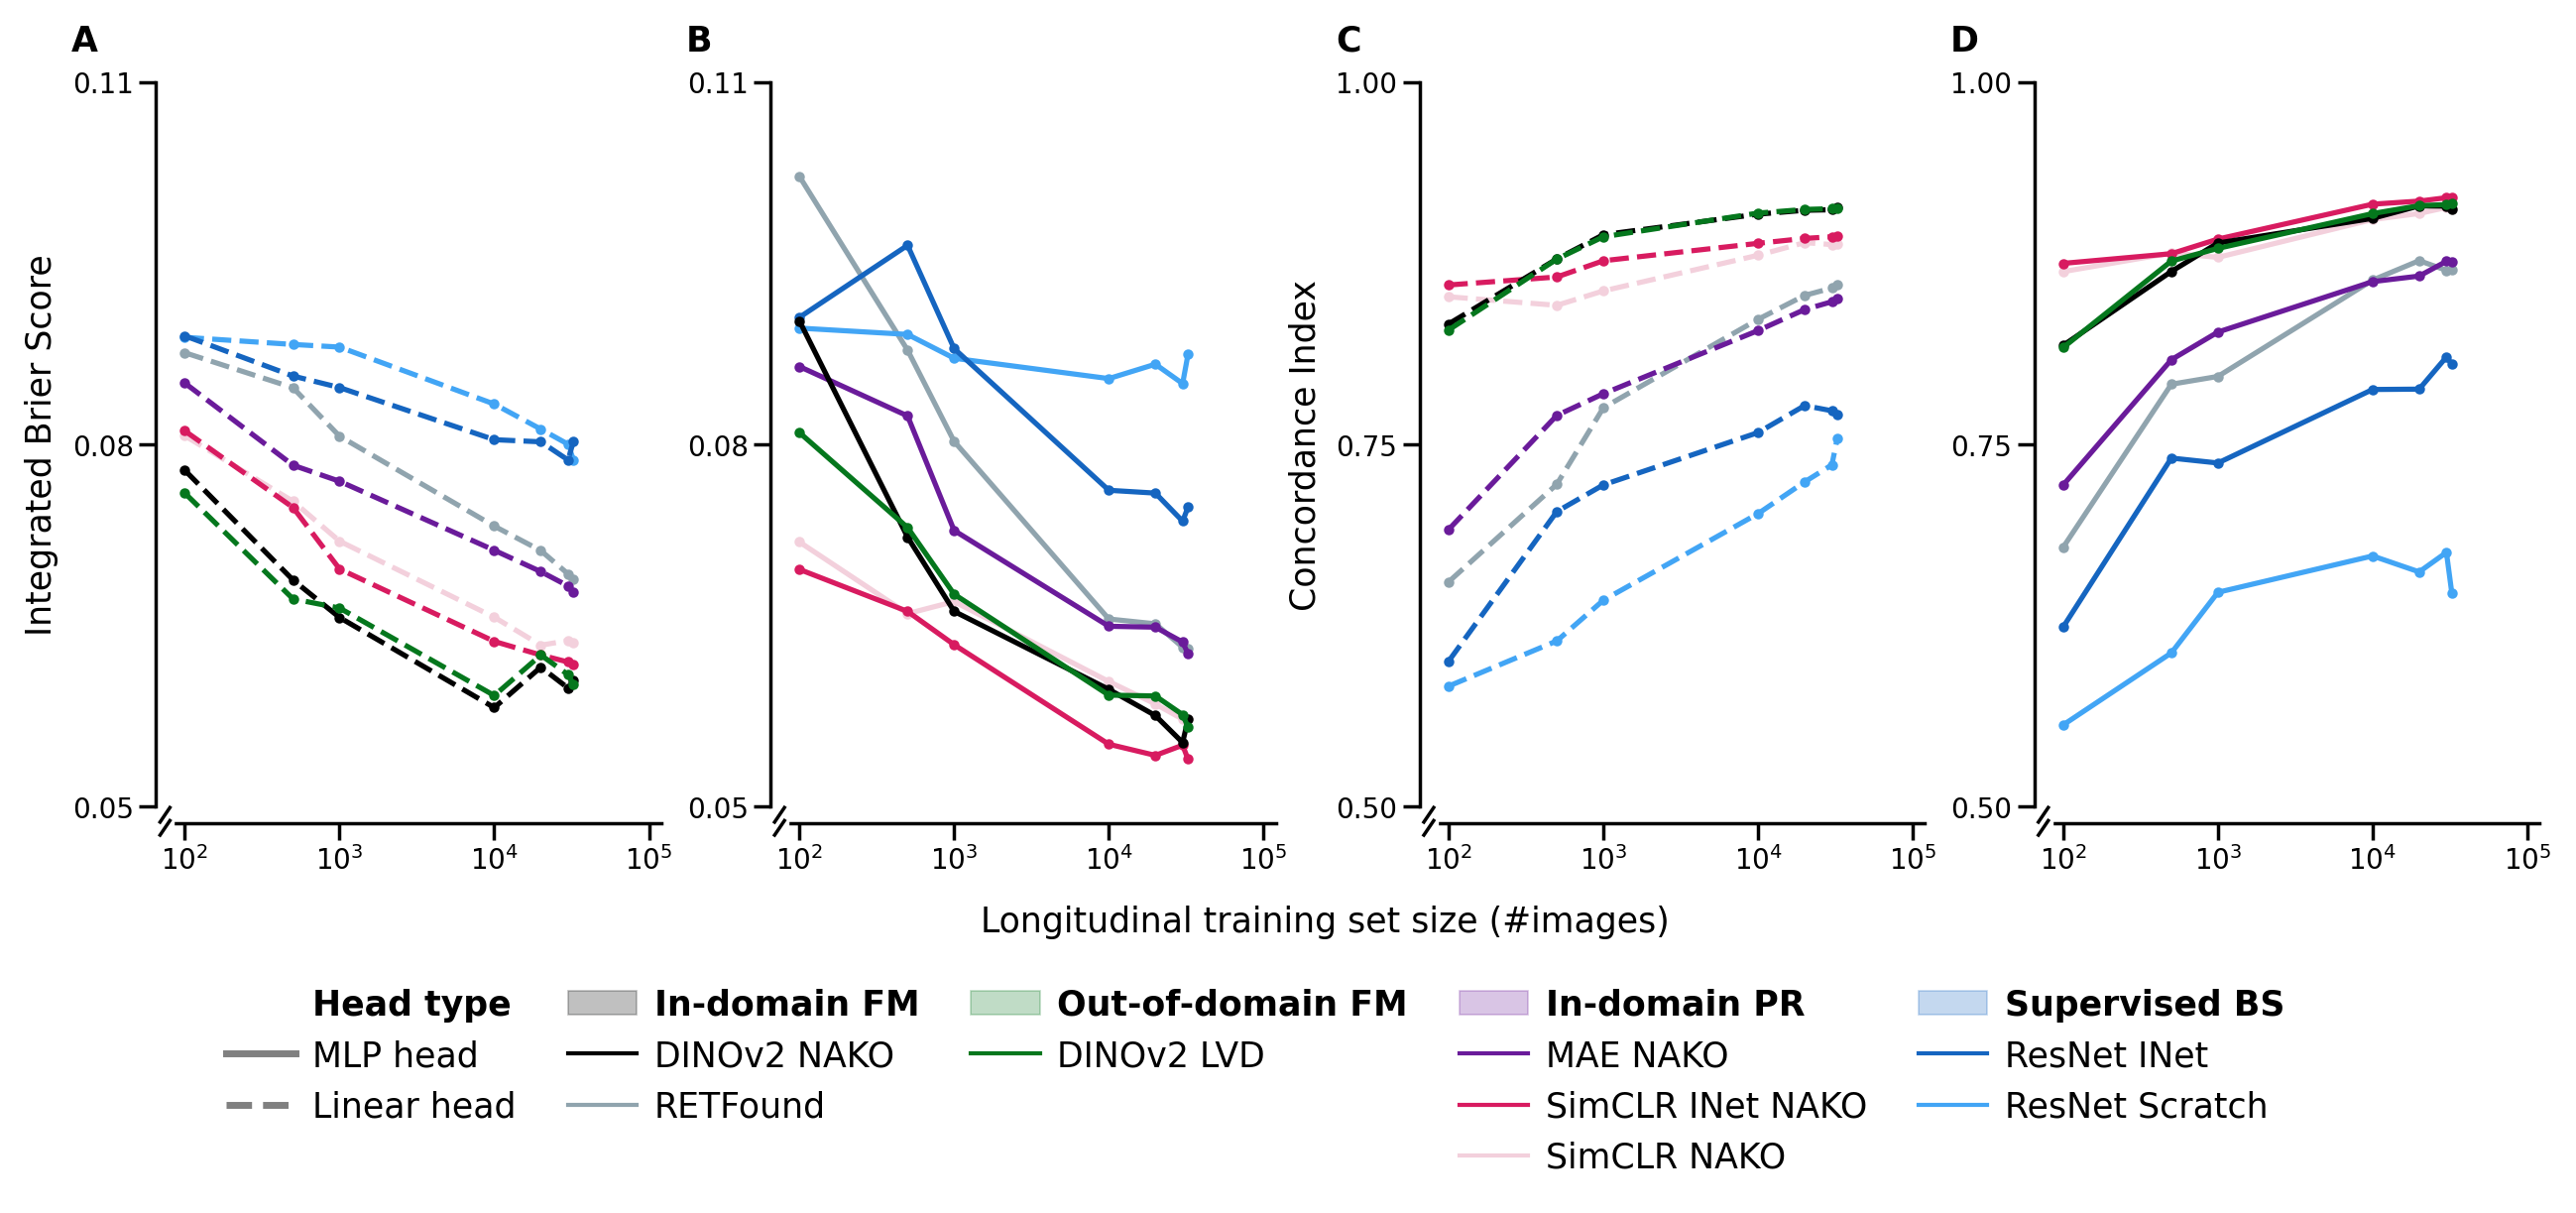

(<Figure size 3500x950 with 4 Axes>,
 array([<Axes: ylabel='Integrated Brier Score'>, <Axes: >,
        <Axes: ylabel='Concordance Index'>, <Axes: >], dtype=object))

In [170]:
plot_finetuning_strategies(fet_plots, show_count=False,
                        more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '0_areds_fet.pdf'), 
                        to_plot = 'mlp',
                        stylef = stylefile, 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      # more negative → more vertical clearance from x-axis
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.08,
                        text_x=-0.2,

)

metrics test/ibs
min y-axis 0.0506, max y-axis 0.0916
metrics test/concordance_index
min y-axis 0.5224, max y-axis 0.9331
10.0
no supxlabel yet


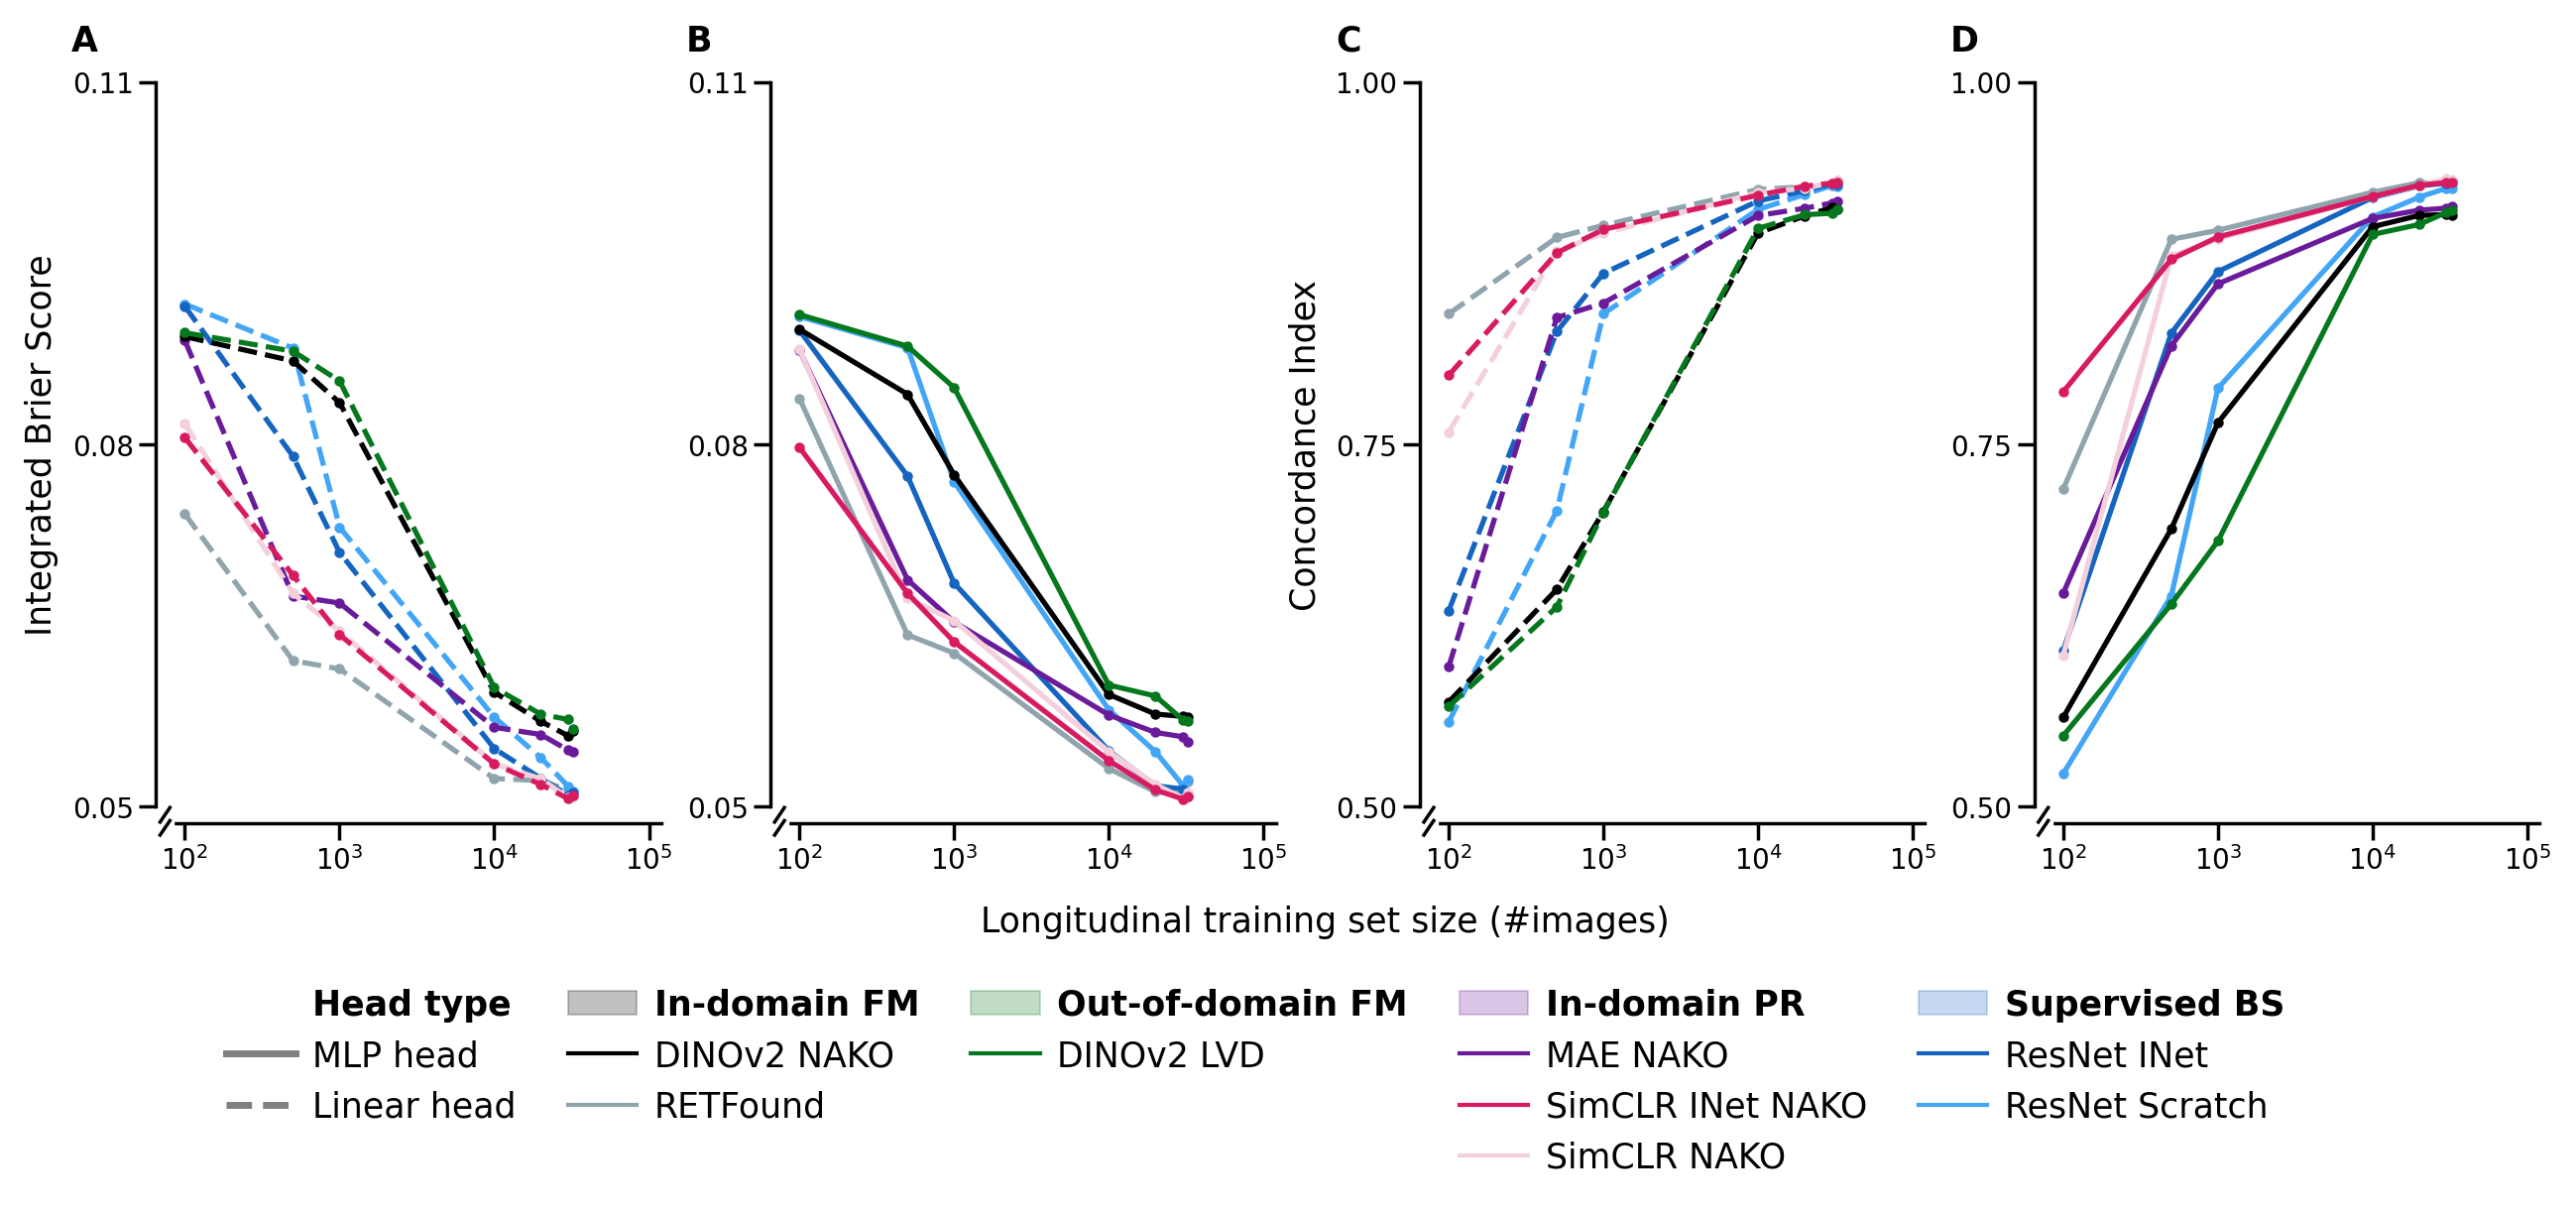

(<Figure size 3500x950 with 4 Axes>,
 array([<Axes: ylabel='Integrated Brier Score'>, <Axes: >,
        <Axes: ylabel='Concordance Index'>, <Axes: >], dtype=object))

In [171]:
plot_finetuning_strategies(fef_plots, show_count=False,
                    more_suptitle = 'Not Freezing Encoder', 
                    save_path = os.path.join(save_path, '0_areds_fef.pdf'), 
                    to_plot = 'mlp',
                    stylef = stylefile, num_y_ticks = 2,  
                    axis_br_size = axis_br_size,
                    axis_br_gap = axis_br_gap, 
                    axis_br_y_pos =axis_br_y_pos, 
                    axis_br_x_pos=axis_br_x_pos,
                    y_ticks_list1 = y_ticks_list1, # [0.05, 0.075, 0.095], 
                    y_ticks_list2=y_ticks_list2, #[0.5, 0.75, 0.95],
                    text_y=1.08,
                                            text_x=-0.2,
)

In [115]:
from plotting_utils import plot_finetuning_strategies_2x2

min y-axis 0.0539, max y-axis 0.1022
min y-axis 0.5561, max y-axis 0.9201


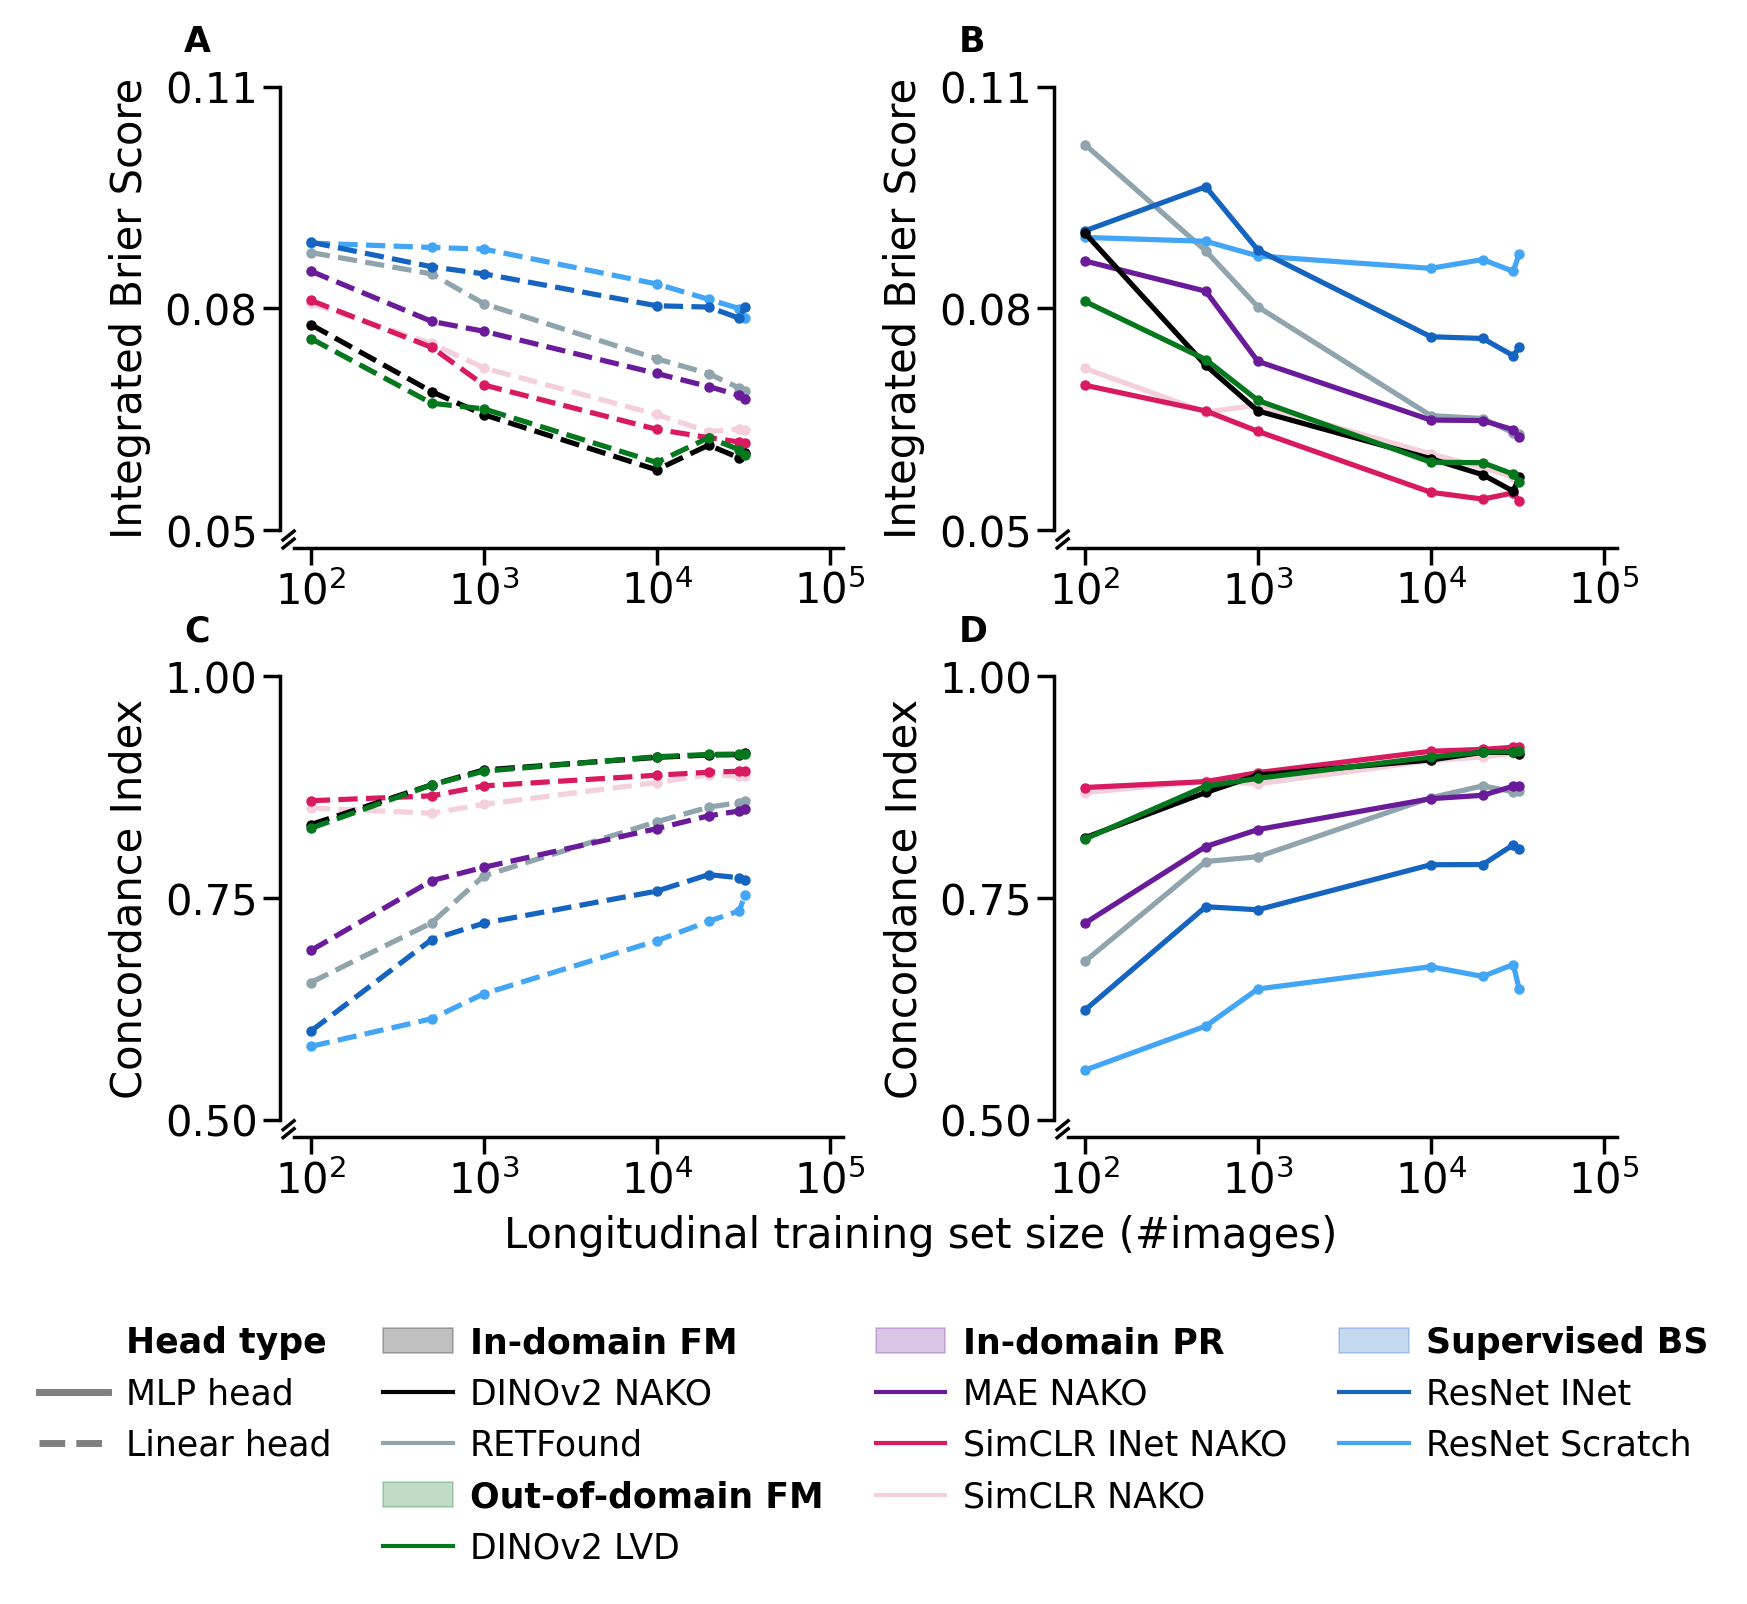

(<Figure size 1566.93x1258.94 with 4 Axes>,
 array([[<Axes: ylabel='Integrated Brier Score'>,
         <Axes: ylabel='Integrated Brier Score'>],
        [<Axes: ylabel='Concordance Index'>,
         <Axes: ylabel='Concordance Index'>]], dtype=object))

In [172]:
plot_finetuning_strategies_2x2(fet_plots, show_count=False,
                        # more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '01_areds_fet.pdf'), 
                        to_plot = 'mlp',
                        stylef = stylefile, 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      # more negative → more vertical clearance from x-axis
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.140,
                        text_x=-0.2
                        )

min y-axis 0.0506, max y-axis 0.0916
min y-axis 0.5224, max y-axis 0.9331


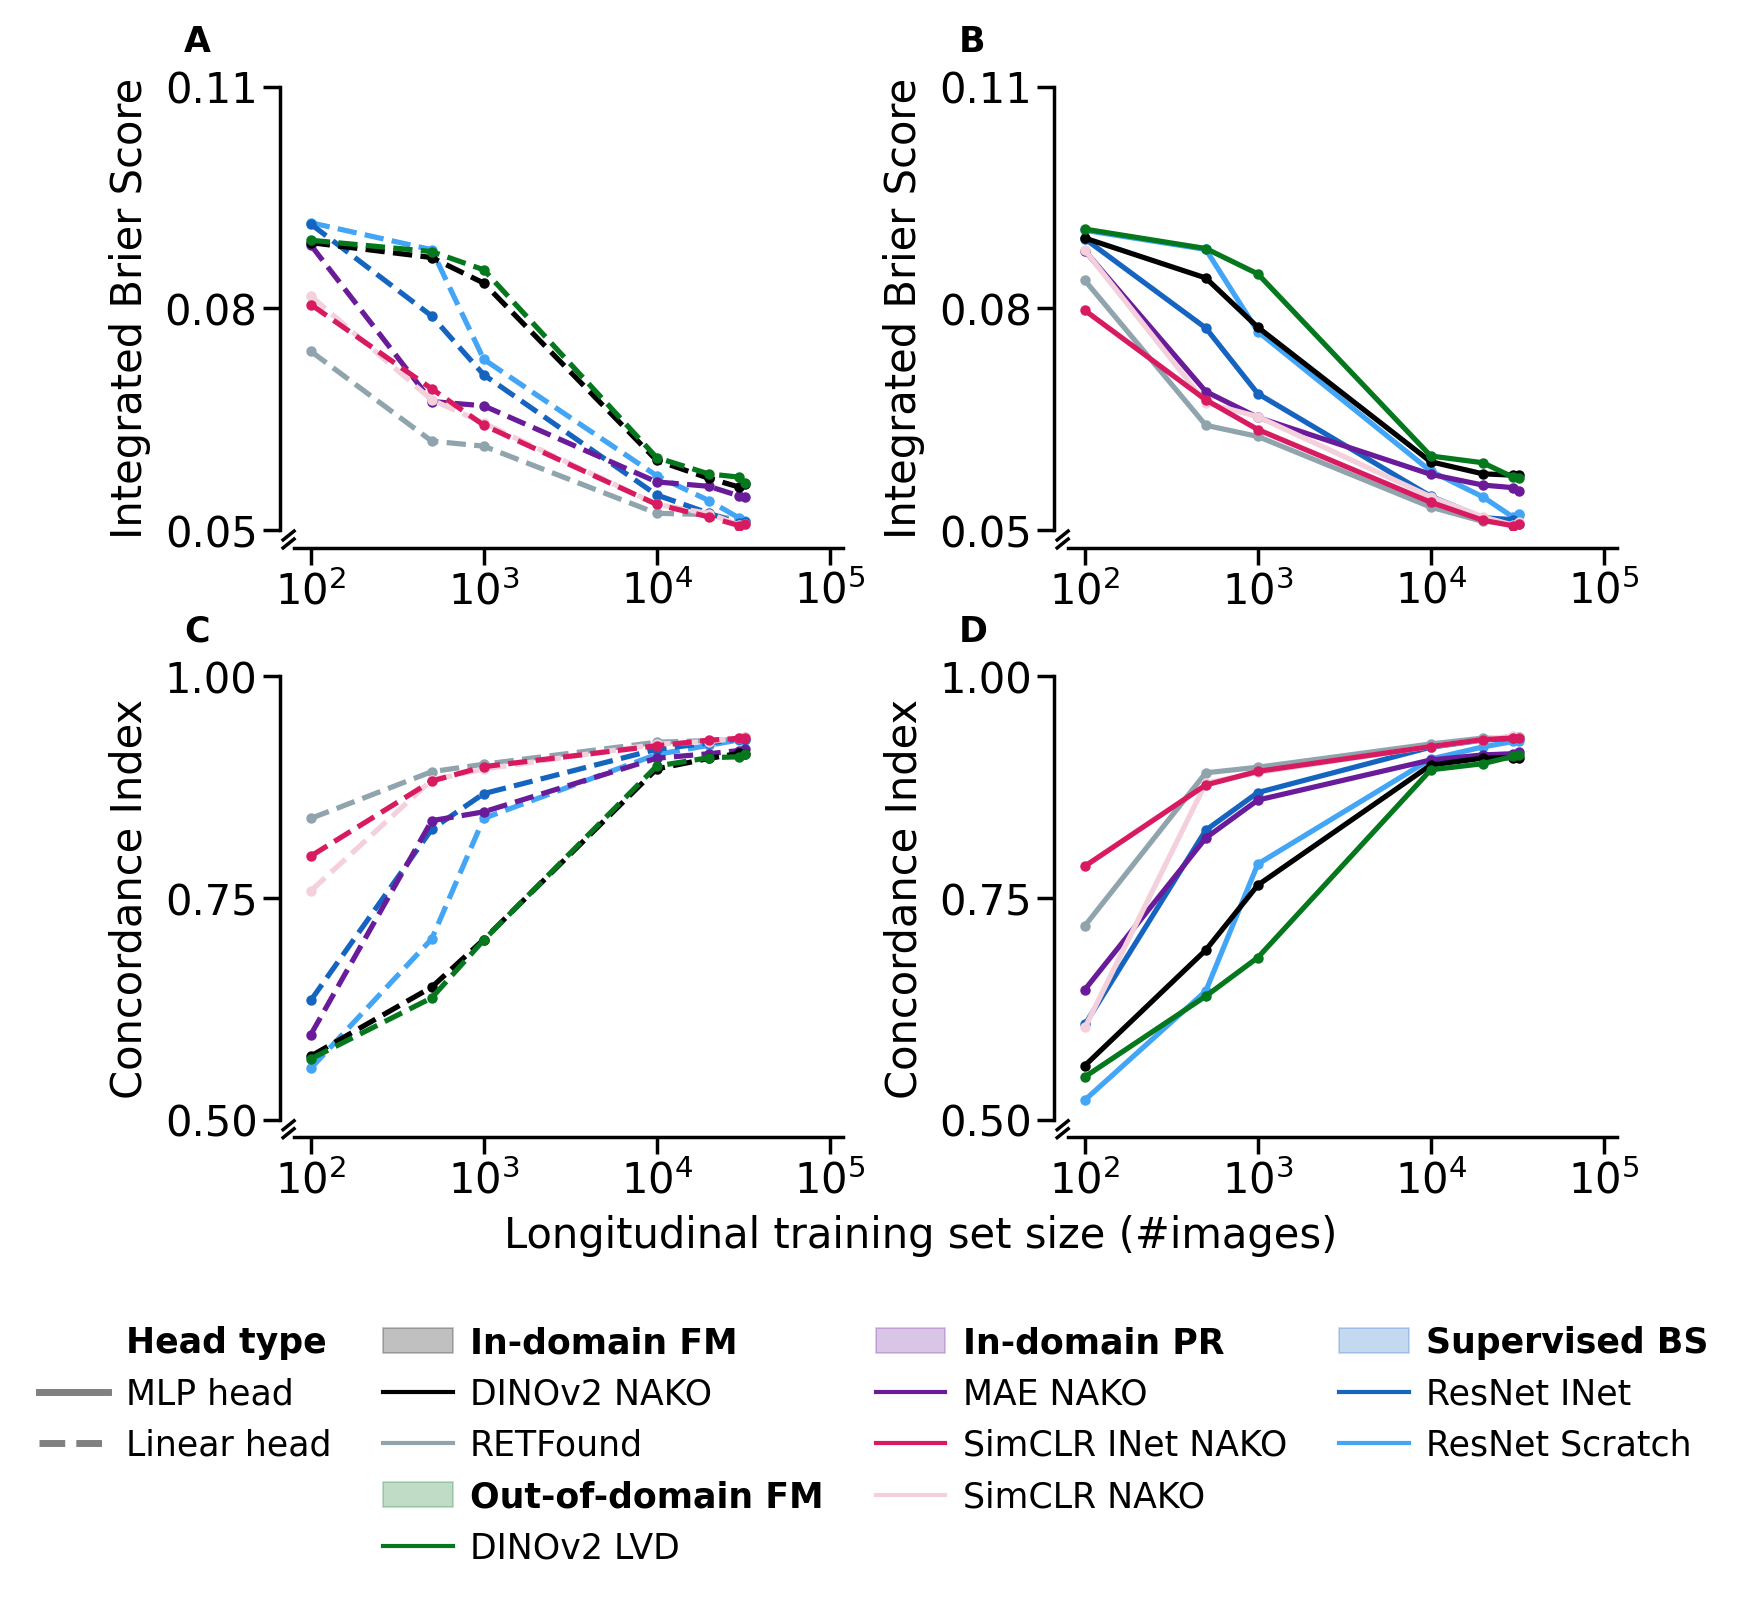

(<Figure size 1566.93x1258.94 with 4 Axes>,
 array([[<Axes: ylabel='Integrated Brier Score'>,
         <Axes: ylabel='Integrated Brier Score'>],
        [<Axes: ylabel='Concordance Index'>,
         <Axes: ylabel='Concordance Index'>]], dtype=object))

In [173]:
plot_finetuning_strategies_2x2(fef_plots, show_count=False,
                        # more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '01_areds_fef.pdf'), 
                        to_plot = 'mlp',
                        stylef = stylefile, 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      # more negative → more vertical clearance from x-axis
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.140,
                        text_x=-0.2)

In [ ]:
# plot_finetuning_strategies(fet_plots, show_count=False, more_suptitle = 'Freezing Encoder', 
# save_path = os.path.join(save_path, '01_areds_fet_concordance_index.pdf'), to_plot = 'mlp',
# metrics='test/concordance_index', stylef = stylefile, num_y_ticks = 2,  
# axis_br_size = 0.012, axis_br_gap = 0.018, axis_br_y_pos = -0.02, 
# # define_ticks=False, use_auto=True,
# y_ticks_list = [0.5, 0.75, 0.95], text_y = 1.08
# )

In [ ]:
# plot_finetuning_strategies(fet_plots, show_count=False, 
#                            more_suptitle = 'Freezing Encoder', 
# save_path = os.path.join(save_path, '1_areds_fet_brier_score_t2.pdf'), to_plot = 'mlp',
# metrics='test/brier_score_t2', stylef = stylefile, num_y_ticks = 2,  
# axis_br_size = 0.012, axis_br_gap = 0.018, axis_br_y_pos = -0.02, 
# y_ticks_list = [0.03, 0.045, 0.065], text_y=0.84
# )

In [ ]:
plot_finetuning_strategies(fef_plots, show_count=False, 
                           more_suptitle = 'Not Freezing Encoder', 
save_path = os.path.join(save_path, '1_areds_fef_ibs.pdf'), to_plot = 'mlp',
metrics='test/ibs', stylef = stylefile, num_y_ticks = 2,  
axis_br_size = 0.012, axis_br_gap = 0.018, axis_br_y_pos = -0.02, 
y_ticks_list = [0.05, 0.075, 0.095])

TypeError: plot_finetuning_strategies() got an unexpected keyword argument 'metrics'

In [ ]:
# plot_finetuning_strategies(fef_plots, show_count=False, 
#                            more_suptitle = 'Not Freezing Encoder', 
# save_path = os.path.join(save_path, '1_areds_fef_brier_score_t2.pdf'),
#  to_plot = 'mlp',
# metrics='test/brier_score_t2', stylef = stylefile, num_y_ticks = 2,  
# axis_br_size = 0.012, axis_br_gap = 0.018, axis_br_y_pos = -0.02, 
# y_ticks_list = [0.03, 0.04, 0.055], text_y = 0.8)

min y-axis 0.5224460009728744, max y axis 0.9331017066587906
yticks [0.5, 0.75, 0.95]
yticks [0.5, 0.75, 0.95]


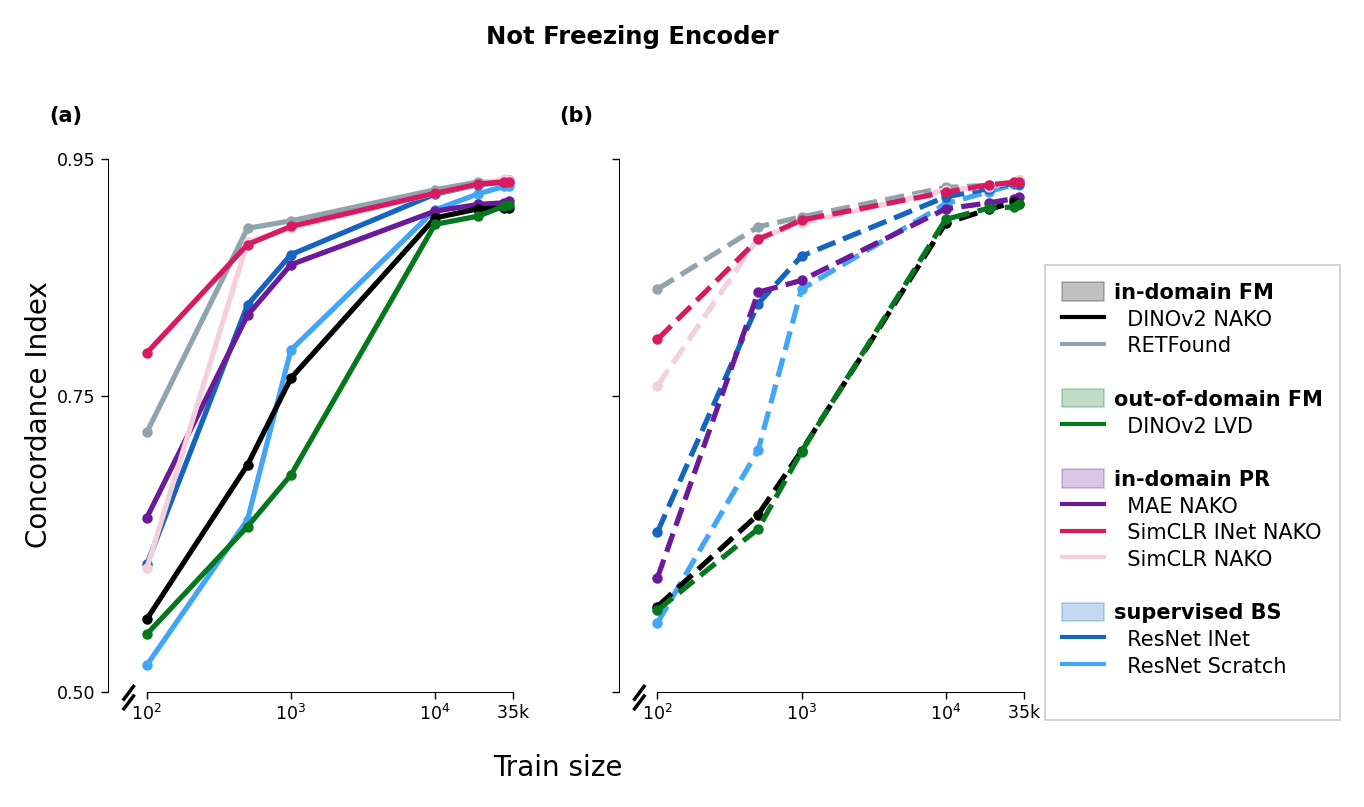

In [ ]:
plot_finetuning_strategies(fef_plots, show_count=False, more_suptitle = 'Not Freezing Encoder', 
save_path = os.path.join(save_path, '1_areds_fef_concordance_index.pdf'), to_plot = 'mlp',
metrics='test/concordance_index', stylef = stylefile, num_y_ticks = 2,  
axis_br_size = 0.012, axis_br_gap = 0.018, axis_br_y_pos = -0.02, 
# define_ticks=False, use_auto=True
y_ticks_list = [0.5, 0.75, 0.95], text_y = 1.1
)

In [ ]:
# plot_finetuning_strategies(mlp_plots, cm_colors, show_count=False, more_suptitle = '', 
# save_path = os.path.join(save_path, 'ibs_mlp_only.pdf'),
# metrics='test/ibs', stylef = stylefile)


In [ ]:
# plot_finetuning_strategies(mlp_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'auc_mlp_only.pdf', ),
# metrics='test/concordance_index', stylef = stylefile, num_y_ticks = 5)

In [ ]:
# plot_finetuning_strategies(mlp_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'auc_mlp_only.pdf'),
# metrics='test/ibs', stylef = stylefile)
# plot_finetuning_strategies(lin_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'auc_lin_only.pdf'), metrics='test/ibs', stylef = stylefile,  num_y_ticks = 10) 

In [ ]:
# plot_finetuning_strategies(lin_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'auc_lin_only.pdf'), metrics='test/concordance_index', stylef = stylefile,  num_y_ticks = 8) 

In [ ]:
# leg = make_publication_legend(ax[1], cm_colors, model_groups, group_colors)

# y_min = 0.053  # just below your data minimum
# y_max = 0.095  # just above your data maximum

# for a in ax:
#     a.set_ylim(y_min, y_max)

#     # y ticks
#     yticks = np.round(np.arange(y_min, y_max + 0.01, 0.01), 2)
#     a.set_yticks(yticks)
#     a.spines['left'].set_bounds(yticks[0], yticks[-1])

#     # x ticks
#     xticks = [100, 1000, 10000, 33000]
#     a.set_xticks(xticks)
#     a.set_xticks([], minor=True)
#     a.xaxis.set_major_formatter(ticker.FuncFormatter(
#         lambda x, _: f'$10^{{{int(np.log10(x))}}}$' if x in [100, 1000, 10000] else f'${int(x/1000)}$k'
#     ))
#     # a.tick_params(axis='x', labelsize=5)#, labelrotation=45
#     # a.xaxis.set_major_formatter(plt.ScalarFormatter())
#     a.spines['bottom'].set_bounds(xticks[0], xticks[-1])

#     sns.despine(ax=a, offset={'left': 6}, trim=False)
#     a.tick_params(labelsize=5)
#     add_axis_break(a, size=0.012, gap=0.018, y_pos=-0.02)

# fig.tight_layout()
# fig.subplots_adjust(right=0.72)

# if save_path:
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [ ]:
# plot_finetuning_strategies(all_plots,cm_colors, metrics='test/ibs', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(all_plots,cm_colors, more_suptitle = 'Truncated Durations', metrics='test/concordance_index', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(all_plots, cm_colors, metrics='test/mean_auroc', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(all_plots,cm_colors, more_suptitle = 'Truncated Durations', metrics='test/mean_auroc', stylef = stylefile)

In [ ]:
# mlp_plots = all_plots.copy()
# lin_plots = all_plots.copy()
# keys_to_delete = [key for key in mlp_plots if 'lin' in key]
# for key in keys_to_delete:
#     del mlp_plots[key]


# l_keys_to_delete = [key for key in lin_plots if 'mlp' in key]
# for key in l_keys_to_delete:
#     del lin_plots[key]

In [ ]:
# plot_finetuning_strategies(mlp_plots,cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'ci_mlp_only.pdf'),
# metrics='test/concordance_index', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(mlp_plots,  show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'ibs_mlp_only.pdf'),
# metrics='test/ibs', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(lin_plots, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'ibs_lin_only.pdf'),
# metrics='test/ibs', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(lin_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'ci_lin_only.pdf'),
# metrics='test/concordance_index', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(lin_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'auc_lin_only.pdf'),
# metrics='test/mean_auroc', stylef = stylefile)

In [ ]:
# plot_finetuning_strategies(mlp_plots, cm_colors, show_count=False, more_suptitle = '', save_path = os.path.join(save_path, 'auc_mlp_only.pdf'),
# metrics='test/mean_auroc', stylef = stylefile)